In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lakshmistm/ml-assessment-data/q1_heart_disease.csv
/kaggle/input/datasets/lakshmistm/ml-assessment-data/q2_customers.csv
/kaggle/input/datasets/lakshmistm/ml-assessment-data/q3_retail_promotions.csv


# Q1: Supervised Learning — Heart Disease Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

## 1. Data Loading and Inspection

In [7]:
df = pd.read_csv('/kaggle/input/datasets/lakshmistm/ml-assessment-data/q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

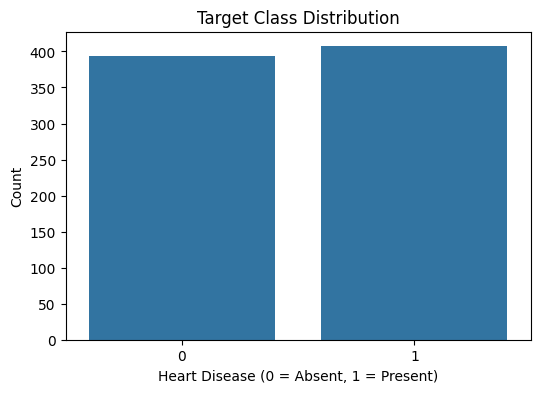

In [8]:
#First Visualisation(bar chart) Target Class Distribution Plot

plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.show()

The chart shows the distribution of the target variable. If the classes are roughly balanced, our models will train fairly. If one class dominates, we may need to account for class imbalance during modelling.

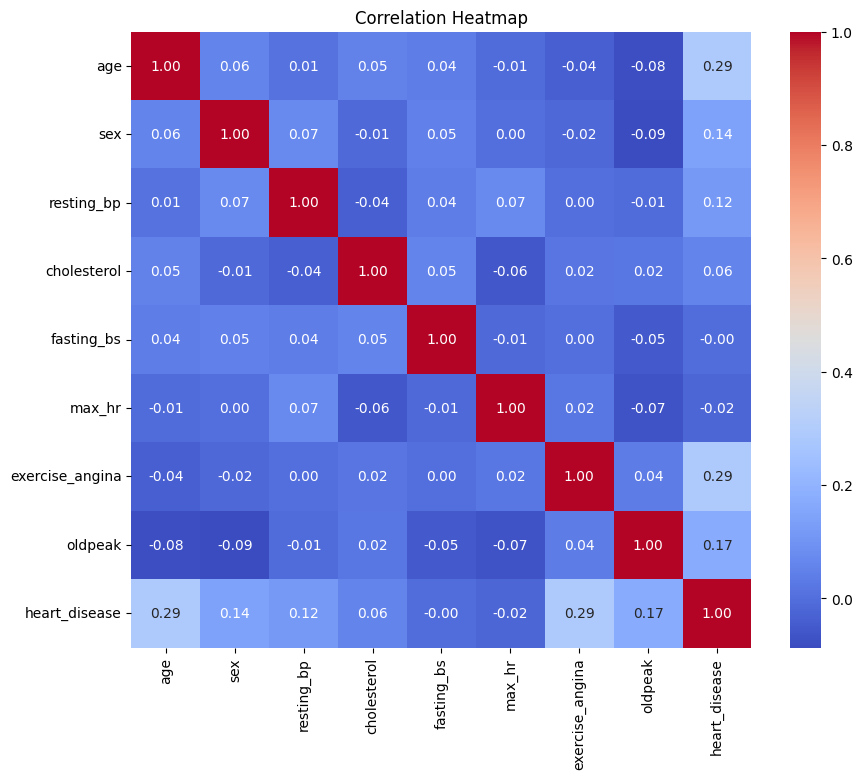

In [9]:
#Second Visualisation(Heatmap)— Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows correlations between numerical features. Features with higher correlation to heart_disease (positive or negative) are likely to be strong predictors. We can also spot multicollinearity — where two input features are highly correlated with each other — which may affect model performance.

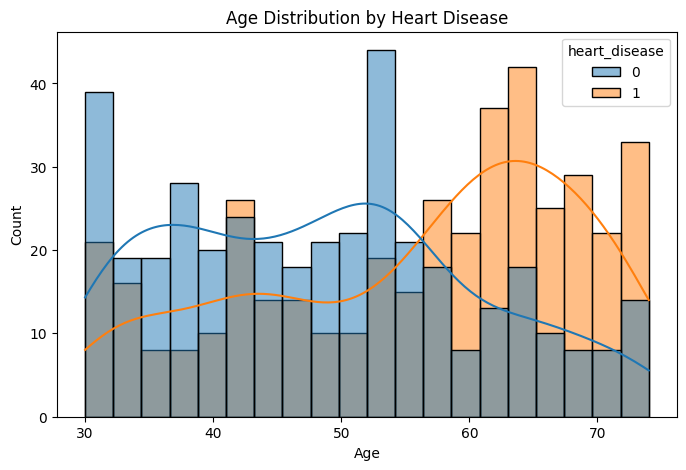

In [10]:
#Third Visualisation(histogram) — Age Distribution by Heart Disease

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='heart_disease', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The histogram shows how age relates to heart disease. If the disease is more prevalent in older patients, age will likely be an important feature in our models. Overlapping distributions suggest age alone is not sufficient to predict the condition.

## 3. Data Preprocessing

Missing values are handled using median imputation for numerical columns. Median is preferred over mean as it is less sensitive to outliers. Categorical columns with missing values are filled with the most frequent value (mode).

In [11]:
# Handle missing values
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (640, 15)
Test set size: (160, 15)


/tmp/ipykernel_55/2152740270.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_55/2152740270.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

## 4. Model Training

In [13]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


## 5. Model Evaluation

In [14]:
models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Decision Tree
Confusion Matrix:
[[56 23]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


Model: Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77     

Random Forest is the best performing model with an F1-score of 0.80 for class 1 (disease present) and 0.79 for class 0 (disease absent), giving a weighted average F1-score of 0.79. This is higher than Decision Tree (0.70) and Gradient Boosting (0.77). The confusion matrix also shows Random Forest makes the fewest misclassifications overall (33 errors vs 48 for Decision Tree and 37 for Gradient Boosting). Therefore Random Forest will be used for hyperparameter tuning.

## 6. Hyperparameter Tuning

In [15]:
#Hyperparameter Tuning

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

y_pred_tuned = grid_search.best_estimator_.predict(X_test)
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



GridSearchCV found the best parameters to be n_estimators=200, max_depth=None, and min_samples_split=2. The tuned model achieved a weighted average F1-score of 0.77, which is slightly lower than the untuned baseline of 0.79. This can happen when the default parameters already perform well on the dataset. The tuning process confirms that the default Random Forest configuration was already near-optimal for this data.